# Base CNN Training for Posture Classification (FP32)

## Imports

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras
import keras_tuner

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset
from bedposip.model import (
    create_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
)

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

TUNE = False


In [15]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [16]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset()


Dataset shapes:
  Train: (119999, 8, 8, 1), labels: (119999,)
  Val:   (60000, 8, 8, 1), labels: (60000,)
  Test:  (120001, 8, 8, 1), labels: (120001,)


### Encoding

In [17]:
class_names = {"lateral_L": 0, "lateral_R": 1, "supine": 2}

## Configuration

In [18]:
# Define callbacks using package function
callbacks = get_callbacks(model_name='base', patience=20)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau


## Base Model

In [19]:
# Create and inspect model
base_model = create_model(num_classes=NUM_CLASSES)
base_model.summary()

check_layer_trainable_params(base_model)

Model: "posture_classifier_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 16)       │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 16)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 24)       │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │         1,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 42)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2 (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,443 (40.79 KB)

 Trainable params: 10,119 (39.53 KB)

 Non-trainable params: 324 (1.27 KB)

conv_1: 144
conv_2: 2304
conv_3: 3456
dense_1: 1008
dense_2: 2688
output: 192


### Training

Epoch 1/50


I0000 00:00:1786044658.737057   18131 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1689846__.49


3723/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7119 - loss: 0.6611

I0000 00:00:1786044665.426228   18134 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1689846__.49


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7772 - loss: 0.5354 - val_accuracy: 0.8387 - val_loss: 0.4050 - learning_rate: 0.0010
Epoch 2/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8462 - loss: 0.3884 - val_accuracy: 0.8669 - val_loss: 0.3401 - learning_rate: 0.0010
Epoch 3/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8664 - loss: 0.3402 - val_accuracy: 0.8849 - val_loss: 0.2955 - learning_rate: 0.0010
Epoch 4/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8779 - loss: 0.3127 - val_accuracy: 0.8904 - val_loss: 0.2825 - learning_rate: 0.0010
Epoch 5/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8850 - loss: 0.2951 - val_accuracy: 0.8966 - val_loss: 0.2690 - learning_rate: 0.0010
Epoch 6/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8906 - loss: 0.2816 - val_accuracy: 0.8942 - val_loss: 0.2768 - learning_rate: 0.0010
Epoch 7/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8954 - loss: 0.271

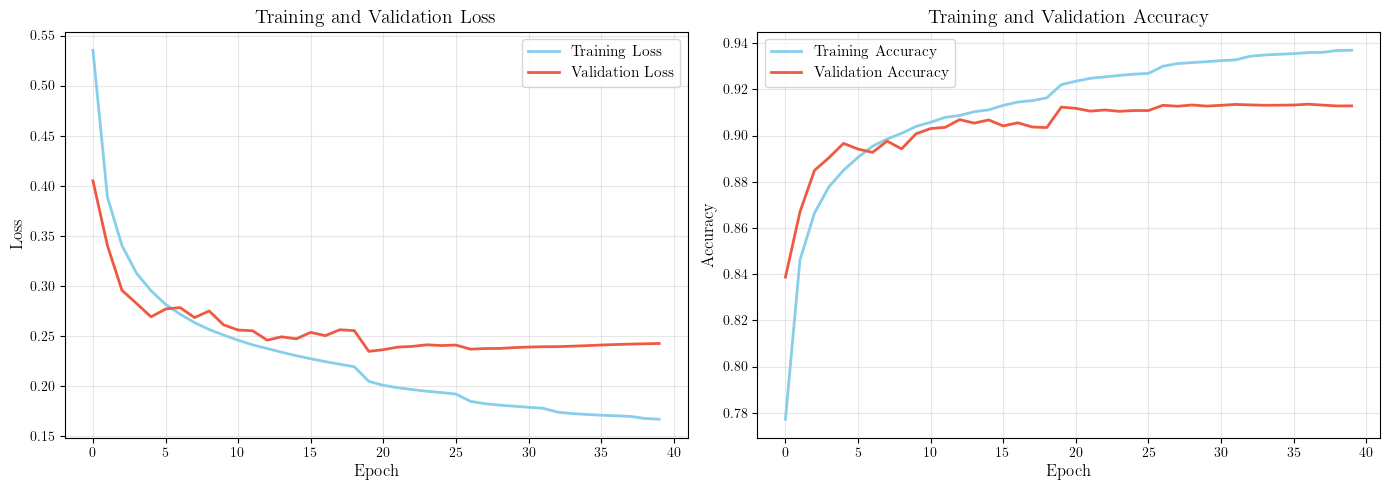

In [20]:
# Train the model
base_history = train_model(
    base_model, X_train, y_train, X_val, y_val, callbacks,
    batch_size=32, epochs=50,
)
plot_training_history(base_history, model_name='posture_classifier_base', save=True)

## Tuned Model

Hyperparameter optimization (KerasTuner)

In [21]:
tuner = keras_tuner.Hyperband(
    hypermodel=create_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    overwrite=TUNE,
    directory='output/tuning',
    project_name='posture_cnn',
    )

tuner.search_space_summary()

Reloading Tuner from output/tuning/posture_cnn/tuner0.json
Search space summary
Default search space size: 6
filters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 24, 'step': 4, 'sampling': 'linear'}
filters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 24, 'step': 4, 'sampling': 'linear'}
filters_3 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 32, 'step': 4, 'sampling': 'linear'}
densefilters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 32, 'step': 4, 'sampling': 'linear'}
densefilters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 32, 'step': 4, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [22]:
tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))
tuned_model = tuner.get_best_models()[0]

tuned_model.summary()

check_layer_trainable_params(tuned_model)

/home/jeison/Nextcloud/PUCMM/ProyectoGrado/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "posture_classifier_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 20)       │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 20)       │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 20)       │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 20)       │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 28)       │         5,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 28)       │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 28)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 28)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 28)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2 (BatchNormalization) │ (None, 24)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,831 (42.31 KB)

 Trainable params: 10,591 (41.37 KB)

 Non-trainable params: 240 (960.00 B)

conv_1: 180
conv_2: 3600
conv_3: 5040
Layer conv_3 is too large (5040), are you sure you want to train?
dense_1: 784
dense_2: 672
output: 72


### Training

Epoch 1/50


I0000 00:00:1786044971.211533   18133 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2596000__.49


3733/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9165 - loss: 0.2198

I0000 00:00:1786044978.188237   18132 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2596000__.49


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9164 - loss: 0.2193 - val_accuracy: 0.9158 - val_loss: 0.2261 - learning_rate: 0.0010
Epoch 2/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9184 - loss: 0.2146 - val_accuracy: 0.9157 - val_loss: 0.2227 - learning_rate: 0.0010
Epoch 3/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9192 - loss: 0.2106 - val_accuracy: 0.9167 - val_loss: 0.2214 - learning_rate: 0.0010
Epoch 4/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9202 - loss: 0.2070 - val_accuracy: 0.9170 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 5/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9223 - loss: 0.2030 - val_accuracy: 0.9168 - val_loss: 0.2228 - learning_rate: 0.0010
Epoch 6/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9233 - loss: 0.2002 - val_accuracy: 0.9152 - val_loss: 0.2266 - learning_rate: 0.0010
Epoch 7/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9246 - loss: 0.197

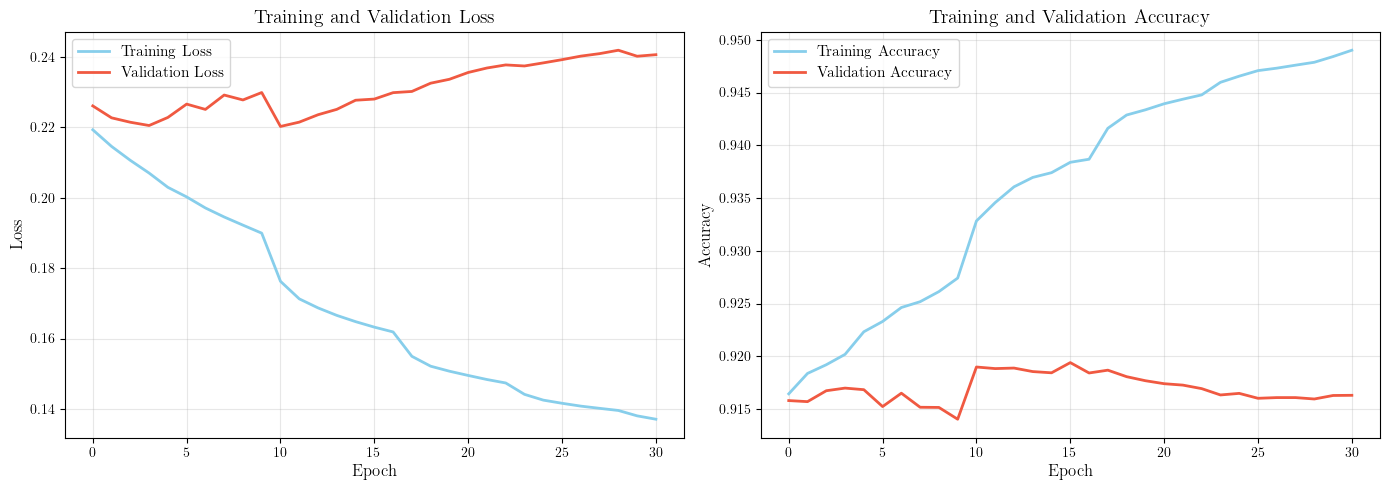

In [23]:
tuned_history = train_model(tuned_model, X_train, y_train, X_val, y_val, callbacks)
plot_training_history(tuned_history, model_name='posture_classifier_tuned', save=True)

## Model Evaluation

### Base Model


Accuracy Report for `posture_classifier_base`:
  Loss: 0.2360
  Accuracy: 91.11%

Classification Report for `posture_classifier_base`:
              precision    recall  f1-score   support

   lateral_L     0.9174    0.9031    0.9102     40000
   lateral_R     0.8984    0.9173    0.9077     40000
      supine     0.9177    0.9128    0.9153     40001

    accuracy                         0.9111    120001
   macro avg     0.9112    0.9111    0.9111    120001
weighted avg     0.9112    0.9111    0.9111    120001

Saved: figures/cm_posture_classifier_base.pdf


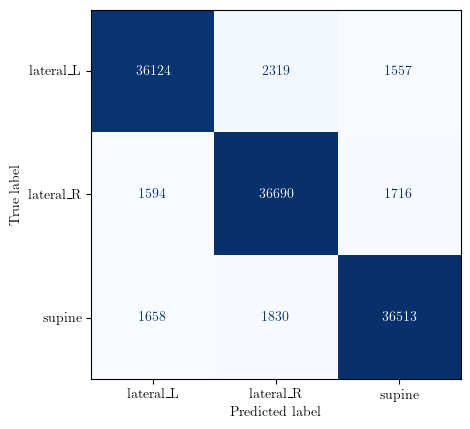

In [24]:
# Classification report for base model
_, _, _ = class_report_metric(base_model, X_test, y_test, class_names, from_logits=False, save=True)

### Tuned Model


Accuracy Report for `posture_classifier_tuned`:
  Loss: 0.2247
  Accuracy: 91.72%

Classification Report for `posture_classifier_tuned`:
              precision    recall  f1-score   support

   lateral_L     0.9272    0.9077    0.9173     40000
   lateral_R     0.9117    0.9146    0.9132     40000
      supine     0.9130    0.9291    0.9210     40001

    accuracy                         0.9172    120001
   macro avg     0.9173    0.9172    0.9172    120001
weighted avg     0.9173    0.9172    0.9172    120001

Saved: figures/cm_posture_classifier_tuned.pdf


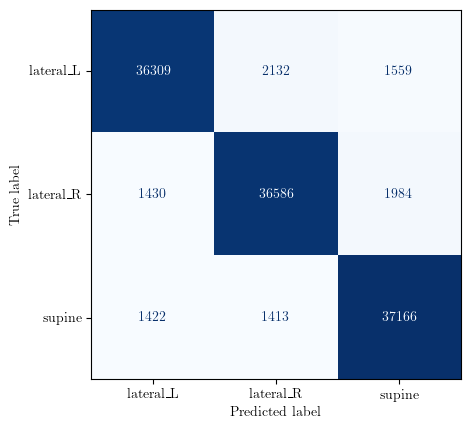

In [25]:
# Classification report for tuned model
_, _, _ = class_report_metric(tuned_model, X_test, y_test, class_names, from_logits=False, save=True)

## Model Saving

In [26]:
# Save models
save_model(base_model, output_dir='output')
save_model(tuned_model, output_dir='output')


Model saved to: output/posture_classifier_base.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_base
  Total parameters: 10,443

Model saved to: output/posture_classifier_tuned.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_tuned
  Total parameters: 10,831
